In [1]:
from numpy import zeros, load, mgrid, vstack
from random import random
from matplotlib.pyplot import figure, axes, subplots, show

#координаты из м в i, j 
def XtoL(pos):
    lc = [pos[0]/dz,pos[1]/dr]
    return lc

#координаты из i, j в м
def Pos(lc):
    pos = [lc[0]*dz,lc[1]*dr]
    return pos

def R(j):
    return (j*dr)

#интерполяция величины из узлов в данную точку 
def gather(data,lc) :
    i = int(lc[0])
    j = int(lc[1])
    di = lc[0] - i
    dj = lc[1] - j
    return  (data[i,j]*(1-di)*(1-dj) + data[i+1,j]*(di)*(1-dj) + data[i,j+1]*(1-di)*(dj) + data[i+1,j+1]*(di)*(dj)) 

#интерполяция value из данной точки в узлы     
def scatter(data,lc,value) :
    i = int(lc[0])
    j = int(lc[1])
    di = lc[0] - i
    dj = lc[1] - j
            
    data[i,j] += (1-di)*(1-dj)*value
    data[i+1,j] += (di)*(1-dj)*value
    data[i,j+1] += (1-di)*(dj)*value
    data[i+1,j+1] += (di)*(dj)*value

#расчет потенциала эл поля (одна итерация)
def solvePotential(phi) :
    
    g = zeros((nz+1,nr+1))
    dz2 = dz*dz
    dr2 = dr*dr

    #Погрешность
    dPhi = 0
           
    for i in range(1,nz-1) :
        #Условие Неймана на левой границе (осевая симметрия)
        phi[i,0] = phi[i,1]
        for j in range(1,nr) :
                
            #На электродах потенциал неизменен (скипаем до следующего j)
            if (cell_type[i,j] > 0) :
                    continue
            
            b = 0
            if i >= int(Z1_EE/dz) :
                b = rho_i[i,j]/EPS0
            g[i,j] = (b + (phi[i,j-1] + phi[i,j+1])/dr2 + (phi[i,j-1] - phi[i,j+1])/(2*dr2*(nr - j)) + (phi[i-1,j] + phi[i+1,j])/dz2)/(2/dr2 + 2/dz2)
                
            #Поиск наибольшей погрешности за одну итерацию  
            if dPhi < abs(g[i,j] - phi[i,j]) :
                dPhi = abs(g[i,j] - phi[i,j])         
            phi[i,j]=g[i,j]
        
        #Условие Неймана на левой и правой границах (осевая симметрия)
        phi[i,0] = phi[i,1]
        phi[i,nr] = phi[i,nr-1]
        
    return phi,dPhi

#Выполнение итераций для расчета потенциала
def laplace_calculate(v) :
    #Критерий прекращения вычислений (погрешность)
    epsilon = 10**(-1)
    dv = epsilon + 1
    #Количество итераций
    S = 0
    while dv >= epsilon :
        v1, dv = solvePotential(v)
        #Подсчет количества итераций
        S += 1
    return v1, S
                                                                                                                                        
#Вычисление электрических полей                  
def computeEF(phi,efz,efr):
    
    #центральная разность, границы не включены
    for i in range(1,nz) :
        for j in range(1,nr) :
            efz[i,j] = -(phi[i+1,j] - phi[i-1,j])/(2*dz)
            efr[i,j] = -(phi[i,j+1] - phi[i,j-1])/(2*dr)
    
    #на границах
    for i in range(1,nz) :
        efz[i,0] = -(phi[i+1,0] - phi[i-1,0])/(2*dz)
        efz[i,nr] = -(phi[i+1,nr] - phi[i-1,nr])/(2*dz)
    for j in range(0,nr) :
        efz[0,j] = -(phi[1,j] - phi[0,j])/dz
        efz[nz,j] = -(phi[nz,j] - phi[nz-1,j])/dz
        if j > 0 and j < nz : 
            efr[nz,j] = -(phi[nz,j+1] - phi[nz,j-1])/2*dr
                                                                                                                                        

In [2]:
#ПАРАМЕТРЫ ЗАДАЧИ

#Потенциал эмиссионного и ускоряющего электродов, В
phi_EE = 1090
phi_AE = -160

#Потенциал плазмы, В
phi_pl = phi_EE + 39

#Бомовская скорость иона вдоль оси z, м/с
v_Bohm = 2811

#Ионный ток на сетку (ток пучка, деленный на прозрачность ЭЭ для ионов), А
Ib = 0.628/0.6

#Количество отверстий в ИОС
Naperture = 3030

#Радиус расчетной области, м
R_max = 1.9*10**(-3)
#Высота расчетной области, м
L_max = 6*R_max

#Количество узлов сетки
nz = 300
nr = 50

#Количество влетающих ионов
dn = 20

#Количество временных шагов
ts = 1600

#РАСЧЕТ

#Размер ячейки в м
dz = L_max/nz
dr = R_max/nr    

#Заряд электрона, а.е.м., диэлектрическая проницаемость
e0 = 1.602*10**(-19) #Заряд электрона, Кл
AMU =  1.673*10**(-27) #кг
EPS0 = 8.854e-12 #Ф*м**(-1)

#Угловая доля сектора
dAlpha = dn/((2*R_max*Ib/(e0*Naperture*v_Bohm))**(2./3.))
print('dn =',dn)
print('dAlpha =',dAlpha)
                                                                                                                                        
charge = e0
m = 83.8*AMU  #Масса иона криптона, кг  
qm = charge/m                   
spwt = 1
                                                                                                                                        
phi = zeros((nz+1,nr+1))                                                                                                                                      
efz = zeros((nz+1,nr+1))
efr = zeros((nz+1,nr+1))
rho_i = zeros((nz+1,nr+1))
den = zeros((nz+1,nr+1))
                                                                                                                                        
#Массив-идентификатор областей
cell_type = zeros((nz+1,nr+1));
R_EE = 15*dr 
R_AE = 25*dr
Z1_EE = 112*dz
Z2_EE = 137*dz
Z1_AE = 162*dz
Z2_AE = 187*dz
for i in range(0,nz+1):
    for j in range(0,nr+1):
        pos = Pos([i,j])  # node position
        
        #EE
        if (pos[1] <= R_EE and pos[0] >= Z1_EE and pos[0] <= Z2_EE) :
            cell_type[i,j] = 1
            phi[i,j] = phi_EE
        
        #AE
        if (pos[1] <= R_AE and pos[0] >= Z1_AE and pos[0] <= Z2_AE) :
            cell_type[i,j] = 2
            phi[i,j] = phi_AE         

for i in range(0,int(Z1_EE/dz)) :
    phi[i,:] = phi_pl 
    
#Вычисление объема ячейки
node_volume = zeros((nr + 1))
for j in range(0,nr + 1) :
    if j == 0 :
        node_volume[j] = dAlpha*3.14*dz*(R_max**2 - (R_max - dr/2)**2)
    elif j == nr :
        node_volume[j] = dAlpha*3.14*dz*(dr/2)**2
    else :
        node_volume[j] = dAlpha*3.14*dz*(((j + 0.5)*dr)**2 - ((j - 0.5)*dr)**2)

#Шаг по времени задается в соответствии с частотой добавления ионов, с
dt = (4*R_max**2*e0*Naperture/(Ib*v_Bohm**2))**(1/3)
print('dt =',dt)

#Создание массива частиц 
part_v = zeros((dn,2))
part_x = zeros((dn,2,ts))

#Тепловая скорость иона вдоль оси z, м/с
part_v[:,0] = v_Bohm 
part_x[0,1,0] = 2*R_max/((dn+1)*(dn+2))
for i in range(1,dn) :
    part_x[i,1,0] = part_x[i-1,1,0] + (i + 1)*2*R_max/((dn+1)*(dn+2))
    
#Индексы частиц, вылетевшых за пределы расчетной области
part_out = zeros(1)
part_out[0] = -1
    
#Вычисление потенциала
phi, phi_iterations = laplace_calculate(phi)
print('phi_iterations =',phi_iterations)
computeEF(phi,efz,efr)  

#from pandas import DataFrame
#df = DataFrame(phi)
#df.to_excel('1000V_minus160V_1000V_cylinder_coordinates_50_150_nodes.xlsx', index=True)

dn = 20
dAlpha = 9.801201690410555e-06
dt = 9.463404772524186e-10
phi_iterations = 1187


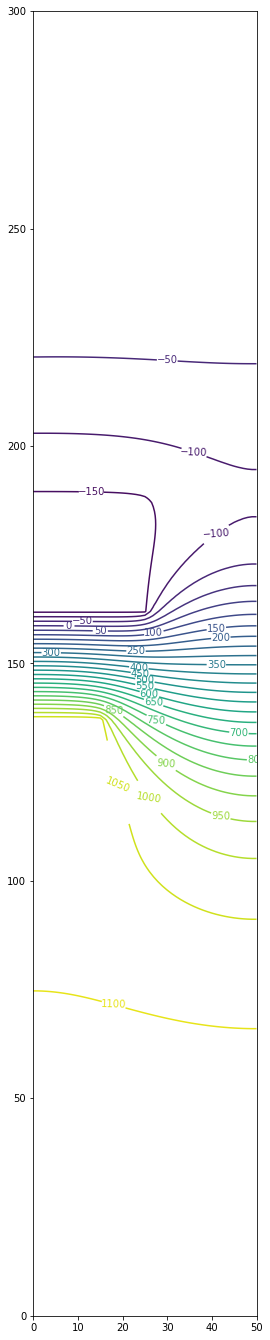

In [3]:
#Размеры расчетной области
a = 0.; c = 2.; b = c*L_max/R_max

#Построение сетки
z, r = mgrid[a:b:10j,a:c:10j]

#Создание графика
fig, ax = subplots()

#Создание эквипотенциалей
cs = ax.contour(phi, levels = 30)

ax.clabel(cs)

#Размеры графика
fig.set_figwidth(4)
fig.set_figheight(24)

#fig.savefig('My_geometry_R_EE_15_1000_-160.png')

show()

In [4]:
#Число частиц, составляющих пучок
N_beam = 0
#Момент времени, когда первая частица достигнет границы ИОС
t_0 = 0
#Число частиц, вернувшихся назад
part_back = 0

for it in range(1,ts-1) :

    den = zeros((nz+1,nr+1))
       
    #Добавление частиц
    if it > 1 :
        part_v_new = zeros((dn,2))
        part_x_new = zeros((dn,2,ts))
        for p in range(0,dn) :
            part_v_new[p,0] = v_Bohm
            part_x_new[p,1,it-1] = part_x[p,1,0]
        part_v = vstack((part_v,part_v_new))
        part_x = vstack((part_x,part_x_new))
    
    np = len(part_x) #размер массива (количество частиц)    
    
    #Перемещение частиц
    for part in range(0,np) : #по всем частицам из массива
        if part in part_out :
            continue
        lc = XtoL(part_x[part,:,it-1]) #коорд частицы из массива из м в i, j
        part_ef = [gather(efz,lc), gather(efr,lc)] #интерполяция эл поля по ячейке в точку
        part_v[part,0] += qm*part_ef[0]*dt #изменение скорости частицы
        part_v[part,1] += qm*part_ef[1]*dt
        part_x[part,0,it] = part_x[part,0,it-1] + part_v[part,0]*dt #изменение положения частицы
        part_x[part,1,it] = part_x[part,1,it-1] + part_v[part,1]*dt
        
        #Подсчет частиц, составляющих пучок
        if part_x[part,0,it] >= Z2_EE and part_x[part,0,it-1] < Z2_EE :
            N_beam += 1
            #Момент времени, когда первая частица достигнет границы ИОС
            if N_beam == 200 :
                t_0 = it
                
        #Подсчет частиц, полетевших назад
        if part_x[part,0,it] < 0 :
            part_back += 1
        
        #Частицы, вылетевшие за пределы расчетной области
        if part_x[part,0,it] > (nz-1)*dz or (part_x[part,0,it] >= Z1_EE and part_x[part,0,it] <= Z2_EE and part_x[part,1,it] <= R_EE) or (part_x[part,0,it] >= Z1_AE and part_x[part,0,it] <= Z2_AE and part_x[part,1,it] <= R_AE) or part_x[part,0,it] < 0 :
            part_out_new = zeros((1))
            part_out_new[0] = part
            part_out = vstack((part_out,part_out_new))
            continue
        
        #Отражение иона на правой оси симметрии
        if part_x[part,1,it] >= nr*dr :
            part_x[part,1,it] = 2*nr*dr - part_x[part,1,it]
            part_v[part,1] = -part_v[part,1]
        
        #Отражение иона на левой оси симметрии
        if part_x[part,1,it] <= 0 :
            part_x[part,1,it] = - part_x[part,1,it]
            part_v[part,1] = -part_v[part,1]
        
        #вычисление плотности зарядов
        lc = XtoL(part_x[part,:,it]) #координаты частицы в i, j        
        scatter(den, lc, spwt) #считаем плотность в каждом узле, добавляя новую частицу с учетом положения (пропорция по площадям)
    
    #нахождение объемной плотности зарядов
    for j in range(0,nr) :
        den[:,j] /= node_volume[j]
    rho_i = charge*den
    
    #пересчет потенциала эл поля
    phi, phi_iterations = laplace_calculate(phi)
    
    #вычисление электрических полей
    computeEF(phi,efz,efr)

In [5]:
print('t_0 =',t_0)
print('N_beam =',N_beam)
print('Particles out:',len(part_out)-1)
print('Particles:',np)

Ib_result = (N_beam - 199)*e0*Naperture/(dAlpha*(ts - t_0)*dt)
Ib_result_0 = np*e0*Naperture/(dAlpha*ts*dt)
print('Ib_result =',Ib_result)
print('Ib =',Ib)
print('Ib_result_0 =',Ib_result_0)
print('part_back =',part_back)

t_0 = 845
N_beam = 9569
Particles out: 15711
Particles: 31960
Ib_result = 0.6494878587196456
Ib = 1.0466666666666666
Ib_result_0 = 1.0453583333333316
part_back = 0


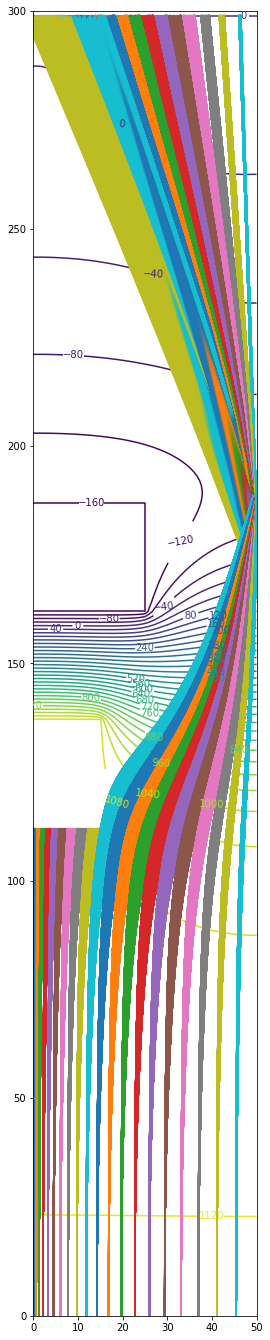

In [6]:
#Размеры расчетной области
a = 0.; c = 2.; b = c*L_max/R_max

#Построение сетки
z, r = mgrid[a:b:10j,a:c:10j]

#Создание графика
fig, ax = subplots()

#Создание эквипотенциалей
cs = ax.contour(phi, levels = 40)

ax.clabel(cs)

#Отрисовка траектории
for N_layer in range(0,ts-2) :
    for k in range(dn*N_layer,dn*N_layer + dn) :
        for it in range(N_layer,ts-1) :
            if (part_x[k,0,it] != 0 and part_x[k,0,it+1] == 0) or it == ts-1 :
                it_2 = it
                ax.plot(part_x[k,1,N_layer:it_2]*nr/R_max,part_x[k,0,N_layer:it_2]*nz/L_max)
                break

#Размеры графика
fig.set_figwidth(4)
fig.set_figheight(24)

show()

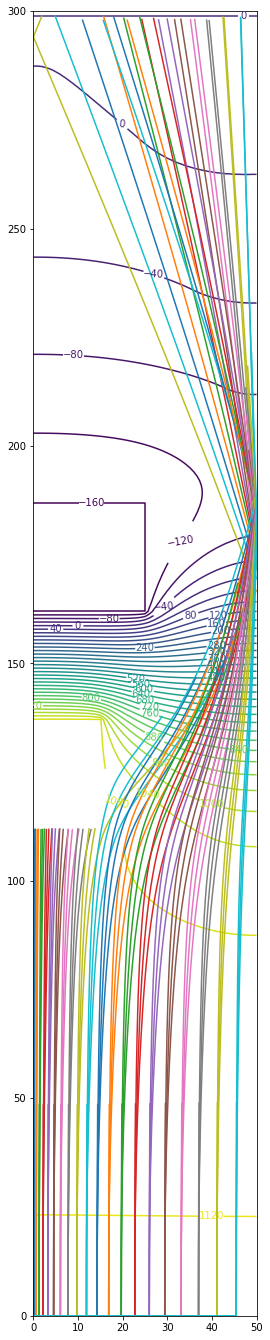

In [7]:
#Размеры расчетной области
a = 0.; c = 2.; b = c*L_max/R_max

#Построение сетки
z, r = mgrid[a:b:10j,a:c:10j]

#Создание графика
fig, ax = subplots()

#Создание эквипотенциалей
cs = ax.contour(phi, levels = 40)

ax.clabel(cs)

#Отрисовка траектории
for N_layer in range(0,4) :
    for k in range(dn*N_layer*400,dn*N_layer*400 + dn) :
        for it in range(N_layer,ts-1) :
            if (part_x[k,0,it] != 0 and part_x[k,0,it+1] == 0) or it == ts-1 :
                it_2 = it
                ax.plot(part_x[k,1,N_layer:it_2]*nr/R_max,part_x[k,0,N_layer:it_2]*nz/L_max)
                break

#Размеры графика
fig.set_figwidth(4)
fig.set_figheight(24)

show()